In [1]:
# 尝试学习CSDN的模型导入方法

In [2]:
import sys
if "ESP32_env" not in sys.executable:
    print("/n环境配置错误!!!/n")
    print(sys.executable)
else:
    print("环境配置正常")

环境配置正常


In [3]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt 
from matplotlib import rcParams # 字体配置,支持中文
rcParams['font.family'] = 'SimHei'
rcParams['axes.unicode_minus'] = False  # 解决负号不显示的问题

import tensorflow as tf

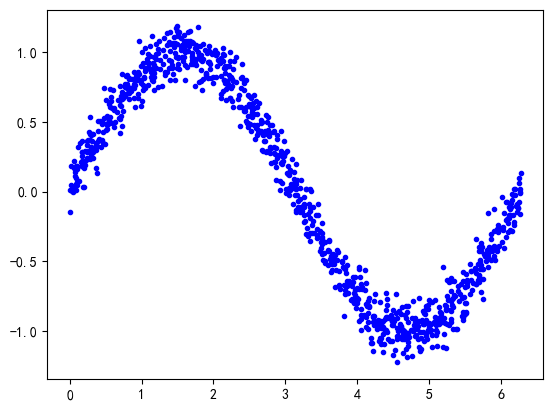

In [4]:
# ===== 1. 数据集构建 =====
import math
# We'll generate this many sample datapoints/设置数据总量
SAMPLES = 1000

# Set a "seed" value, so we get the same random numbers each time we run this
# notebook. Any number can be used here.
SEED = 1337
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Generate a uniformly distributed set of random numbers in the range from
# 0 to 2π, which covers a complete sine wave oscillation/设置生成数据格式
x_values = np.random.uniform(low=0, high=2*math.pi, size=SAMPLES)

# Shuffle the values to guarantee they're not in order/打乱数据的顺序
np.random.shuffle(x_values)

# Calculate the corresponding sine values/使用sin方法计算正弦值
y_values = np.sin(x_values)

# Add a small random number to each y value
y_values += 0.1 * np.random.randn(*y_values.shape)  # 添加noise

# Plot our data/使用matplotlib绘制图形
plt.plot(x_values, y_values, 'b.')
plt.show()

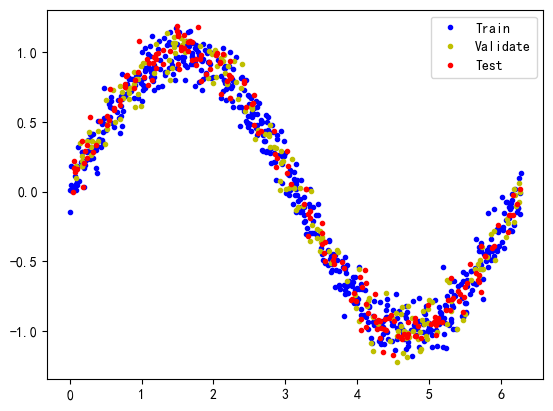

In [5]:
# 2. 拆分数据:训练数据、验证数据、测试数据
# We'll use 60% of our data for training and 20% for testing. The remaining 20%
# will be used for validation. Calculate the indices of each section.
TRAIN_SPLIT =  int(0.6 * SAMPLES)
TEST_SPLIT = int(0.2 * SAMPLES + TRAIN_SPLIT)
# 通过split方法拆分数据
x_train, x_validate, x_test = np.split(x_values, [TRAIN_SPLIT, TEST_SPLIT])
y_train, y_validate, y_test = np.split(y_values, [TRAIN_SPLIT, TEST_SPLIT])

plt.plot(x_train, y_train, 'b.', label="Train")
plt.plot(x_validate, y_validate, 'y.', label="Validate")
plt.plot(x_test, y_test, 'r.', label="Test")
plt.legend()
plt.show()

In [6]:
# 3. 设计训练模型
import tensorflow as tf
from tensorflow.keras import layers 
# 使用keras创建一个序列模型Sequential
model_2 = tf.keras.Sequential()

# First layer takes a scalar input and feeds it through 16 "neurons". The
# neurons decide whether to activate based on the 'relu' activation function.
# 第一层使用16个神经元；activation：激活函数，选择relu策略，他返回两个数中较大的值。
model_2.add(layers.Dense(16, activation='relu', input_shape=(1,)))

# The new second layer may help the network learn more complex representations
# 第二层神经元模型
model_2.add(layers.Dense(16, activation='relu'))

# Final layer is a single neuron, since we want to output a single value
#第三层神经元模型
model_2.add(layers.Dense(1))

# Compile the model using a standard optimizer and loss function for regression
# 设置训练过程中的参数 optimizer：优化器在训练期间用于调整网络对其输入进行建模的算法。
# loss：损失值在训练期间计算模型预测值与真实值之间的差距，mse代表均方误差（Mean Squared Error），
# 它是预测值与真实值之差的平方的平均值。
# metrics：用于评估模型性能的指标列表

model_2.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])

# Show a summary of the model
# 输出设计的模型架构摘要
model_2.summary()


d:\conda_envs\ESP32_env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# 4. 训练模型
# 调用fit方法训练模型
# history_2：接收训练返回的数据
# x_train, y_train：训练数据x和y值
# epochs：训练次数
# batch_size：每次训练输入多少个数据，每一轮训练完成就会更新一次神经元模型，如果设置1就要更新600次，增加训练时间，
# 如果设置600，则每轮训练包含所有数据这样是快了，但是准确度降低了。因此设置为每论随机取16个数据训练。
# validation_data：验证数据，验证在训练过程中模型的预测和实际正确值是否一致。
history_2 = model_2.fit(x_train, y_train, epochs=600, batch_size=16,
                    validation_data=(x_validate, y_validate))

Epoch 1/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4093 - mae: 0.5587 - val_loss: 0.3827 - val_mae: 0.5355
Epoch 2/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3318 - mae: 0.4997 - val_loss: 0.3173 - val_mae: 0.4844
Epoch 3/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2790 - mae: 0.4595 - val_loss: 0.2676 - val_mae: 0.4446
Epoch 4/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2383 - mae: 0.4253 - val_loss: 0.2301 - val_mae: 0.4129
Epoch 5/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2085 - mae: 0.3986 - val_loss: 0.2035 - val_mae: 0.3892
Epoch 6/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1879 - mae: 0.3778 - val_loss: 0.1851 - val_mae: 0.3720
Epoch 7/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1751 - mae: 0.3628 - val_loss: 0.1740 - val_mae: 0.3589
Epoch 8/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1676 - mae: 0.3522 - val_loss: 0.1673 - val_mae: 0.3499
Epoch 9/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.163

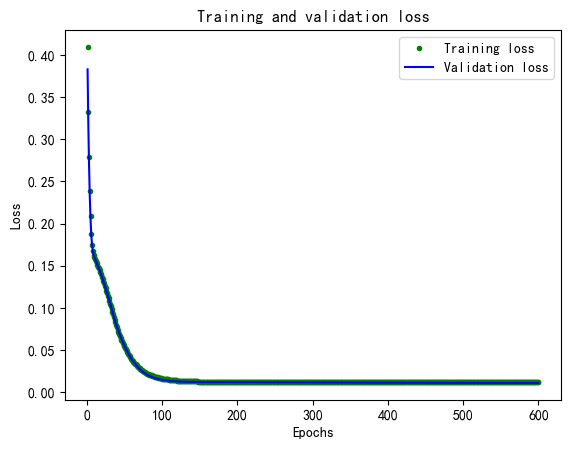

In [8]:
# 5. 分析运算结果
# 5-1 绘制训练损失和验证损失图
#绘制训练损失和验证损失图
# Draw a graph of the loss, which is the distance between
# the predicted and actual values during training and validation.
# 分别从历史数据中提取出损失数据loss和验证数据val_loss
loss = history_2.history['loss']
val_loss = history_2.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'g.', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


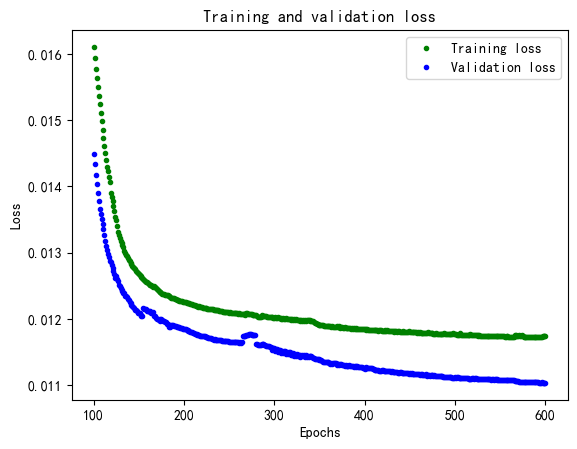

In [9]:
# 5-2 绘制训练损失和验证损失详情图
# 跳过前100次，查看后面500次训练损失和验证损失详细数据
# Exclude the first few epochs so the graph is easier to read
#设置跳过的次数
SKIP = 100

plt.clf()

plt.plot(epochs[SKIP:], loss[SKIP:], 'g.', label='Training loss')
plt.plot(epochs[SKIP:], val_loss[SKIP:], 'b.', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()



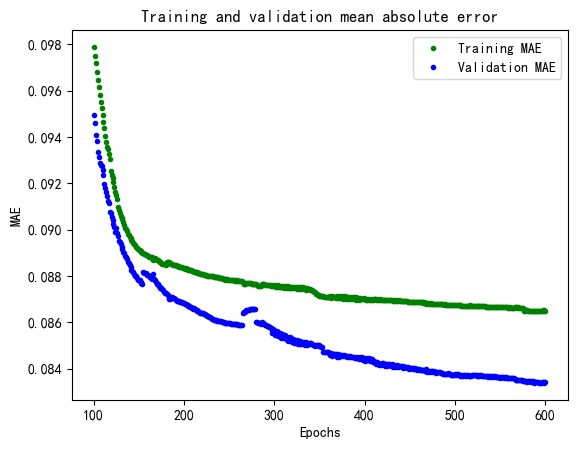

In [10]:
# 5-3 绘制平均绝对误差
#使用上面相同轮次，绘制下面的图形。
plt.clf()

# Draw a graph of mean absolute error, which is another way of
# measuring the amount of error in the prediction.
mae = history_2.history['mae']
val_mae = history_2.history['val_mae']

plt.plot(epochs[SKIP:], mae[SKIP:], 'g.', label='Training MAE')
plt.plot(epochs[SKIP:], val_mae[SKIP:], 'b.', label='Validation MAE')
plt.title('Training and validation mean absolute error')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


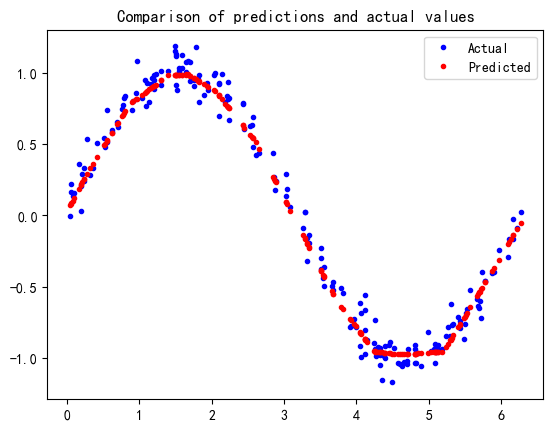

In [11]:
# 5-4 绘制训练数据的预期值和期望值
# 训练数据的预测值和期望值
# Make predictions based on our test dataset
predictions = model_2.predict(x_test)

# Graph the predictions against the actual values
plt.clf()
plt.title('Comparison of predictions and actual values')
plt.plot(x_test, y_test, 'b.', label='Actual')
plt.plot(x_test, predictions, 'r.', label='Predicted')
plt.legend()
plt.show()


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0095 - mae: 0.0761 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


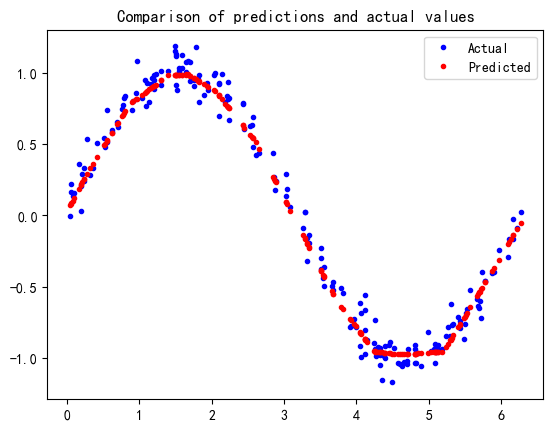

In [12]:
# 6. 测试模型
# Calculate and print the loss on our test dataset 
#使用测试数据调用evaluate方法计算损失值和平均绝对误差值，
loss = model_2.evaluate(x_test, y_test)

# Make predictions based on our test dataset
#使用测试数据计算预测值
predictions = model_2.predict(x_test)

# Graph the predictions against the actual values
plt.clf()

plt.title('Comparison of predictions and actual values')
# 绘制测试数据直接结果
plt.plot(x_test, y_test, 'b.', label='Actual')
# 绘制测试数据预测结果
plt.plot(x_test, predictions, 'r.', label='Predicted')
plt.legend()
plt.show()


In [13]:
# 7. =============== 导出模型 ===============

In [14]:
# 7-1 转化模型(两种方案对比:普通转化vs压缩转化)
# Convert the model to the TensorFlow Lite format without quantization
# 只将模型转化，不做优化。
converter = tf.lite.TFLiteConverter.from_keras_model(model_2)
tflite_model = converter.convert()

# Save the model to disk
open("sine_model.tflite", "wb").write(tflite_model)

# Convert the model to the TensorFlow Lite format with quantization
# 对模型转化并使用了优化压缩模型体积
converter = tf.lite.TFLiteConverter.from_keras_model(model_2)
# Indicate that we want to perform the default optimizations,
# which includes quantization
# 使用优化器
converter.optimizations = [tf.lite.Optimize.DEFAULT]
# Define a generator function that provides our test data's x values
# as a representative dataset, and tell the converter to use it
def representative_dataset_generator():
  for value in x_test:
    # Each scalar value must be inside of a 2D array that is wrapped in a list
    yield [np.array(value, dtype=np.float32, ndmin=2)]
converter.representative_dataset = representative_dataset_generator
# Convert the model
tflite_model = converter.convert()

# Save the model to disk
open("sine_model_quantized.tflite", "wb").write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\lxl\AppData\Local\Temp\tmp1_eqlk0t\assets


INFO:tensorflow:Assets written to: C:\Users\lxl\AppData\Local\Temp\tmp1_eqlk0t\assets


Saved artifact at 'C:\Users\lxl\AppData\Local\Temp\tmp1_eqlk0t'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2098555951568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2098555952720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2098555951952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2098555950608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2098555950416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2098555951184: TensorSpec(shape=(), dtype=tf.resource, name=None)
INFO:tensorflow:Assets written to: C:\Users\lxl\AppData\Local\Temp\tmp5zlot9tr\assets


INFO:tensorflow:Assets written to: C:\Users\lxl\AppData\Local\Temp\tmp5zlot9tr\assets


Saved artifact at 'C:\Users\lxl\AppData\Local\Temp\tmp5zlot9tr'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2098555951568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2098555952720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2098555951952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2098555950608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2098555950416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2098555951184: TensorSpec(shape=(), dtype=tf.resource, name=None)


d:\conda_envs\ESP32_env\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


3712

d:\conda_envs\ESP32_env\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


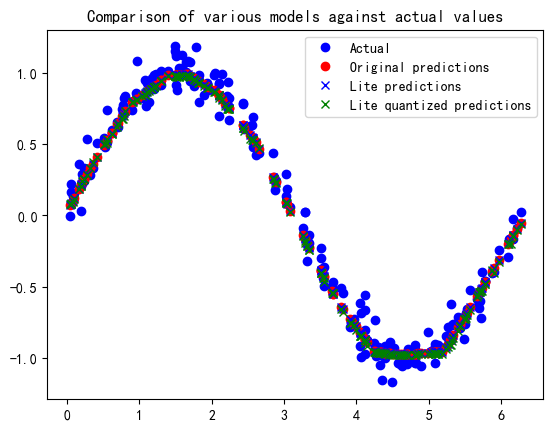

In [15]:
# 7-2 模型对比
# Instantiate an interpreter for each model
sine_model = tf.lite.Interpreter('sine_model.tflite')
sine_model_quantized = tf.lite.Interpreter('sine_model_quantized.tflite')

# Allocate memory for each model
sine_model.allocate_tensors()
sine_model_quantized.allocate_tensors()

# Get indexes of the input and output tensors
sine_model_input_index = sine_model.get_input_details()[0]["index"]
sine_model_output_index = sine_model.get_output_details()[0]["index"]
sine_model_quantized_input_index = sine_model_quantized.get_input_details()[0]["index"]
sine_model_quantized_output_index = sine_model_quantized.get_output_details()[0]["index"]

# Create arrays to store the results
sine_model_predictions = []
sine_model_quantized_predictions = []

# Run each model's interpreter for each value and store the results in arrays
for x_value in x_test:
  # Create a 2D tensor wrapping the current x value
  x_value_tensor = tf.convert_to_tensor([[x_value]], dtype=np.float32)
  # Write the value to the input tensor
  sine_model.set_tensor(sine_model_input_index, x_value_tensor)
  # Run inference
  sine_model.invoke()
  # Read the prediction from the output tensor
  sine_model_predictions.append(
      sine_model.get_tensor(sine_model_output_index)[0])
  # Do the same for the quantized model
  sine_model_quantized.set_tensor(sine_model_quantized_input_index, x_value_tensor)
  sine_model_quantized.invoke()
  sine_model_quantized_predictions.append(
      sine_model_quantized.get_tensor(sine_model_quantized_output_index)[0])


# See how they line up with the data
plt.clf()
plt.title('Comparison of various models against actual values')
plt.plot(x_test, y_test, 'bo', label='Actual')
plt.plot(x_test, predictions, 'ro', label='Original predictions')
plt.plot(x_test, sine_model_predictions, 'bx', label='Lite predictions')
plt.plot(x_test, sine_model_quantized_predictions, 'gx', label='Lite quantized predictions')
plt.legend()
plt.show()


In [ ]:
# 8. 标准化模型(使用xxd工具)
# 在.tflite文件地址打开shell,然后执行下面的指令即可
'''
# 1. 将.tflite文件转为.cc文件
# Install xxd if it is not available
apt-get -qq install xxd
# Save the file as a C source file
# 将模型格式化为C语言文件
xxd -i sine_model_quantized.tflite > sine_model_quantized.cc
# Print the source file
# 查看C语言文件模型内容
cat sine_model_quantized.cc

# 2. 将模型格式化为C语言的.h文件
xxd -i sine_model_quantized.tflite > sine_model.h
# Print the source file
# 查看C语言文件模型内容
cat sine_model.h
'''